In [109]:
import matplotlib.pyplot as plt
import pandas as pd
import os


In [110]:
filepath = "results/results.csv"
df = pd.read_csv(filepath)
df.head(5)

,instance,method,run,seed,makespan,decode_calls,time,lower_bound,optimum,optimum_source
0,mini3,local_search,0,7,11,200000,0.878,10,11,bruteforce
1,mini3,local_search,1,1007,11,200000,0.871,10,11,bruteforce
2,mini3,local_search,2,2007,11,200000,0.891,10,11,bruteforce
3,mini3,local_search,3,3007,11,200000,0.830,10,11,bruteforce
4,mini3,local_search,4,4007,11,200000,0.832,10,11,bruteforce


In [111]:
df["gap"] = (df.makespan - df.optimum) / df.optimum * 100

In [112]:
METHOD_NAME = {
    "annealing": "Annealing",
    "vns": "VNS",
    "ga": "GA",
    "local_search": "Loc. Search"
}
df["method_label"] = df.method.map(METHOD_NAME)

df.to_csv("data/results-transformed.csv", index=False)


In [113]:

df = pd.read_csv("data/results-transformed.csv")

In [ ]:
PROBLEMS = ["mini3", "ft06","la01","la02","la03","la04","la05","ft10","ft20"]
METHODS = ["annealing", "vns", "ga", "local_search"]
LABELS  = ["kaljenje", "vns", "ga", "lok.pretraga"]
BUDGET  = 200_000

/tmp/ipykernel_1533207/1592099286.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8,loc="lower right")
/tmp/ipykernel_1533207/1592099286.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8,loc="lower right")
/tmp/ipykernel_1533207/1592099286.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8,loc="lower right")
/tmp/ipykernel_1533207/1592099286.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8,loc="lo

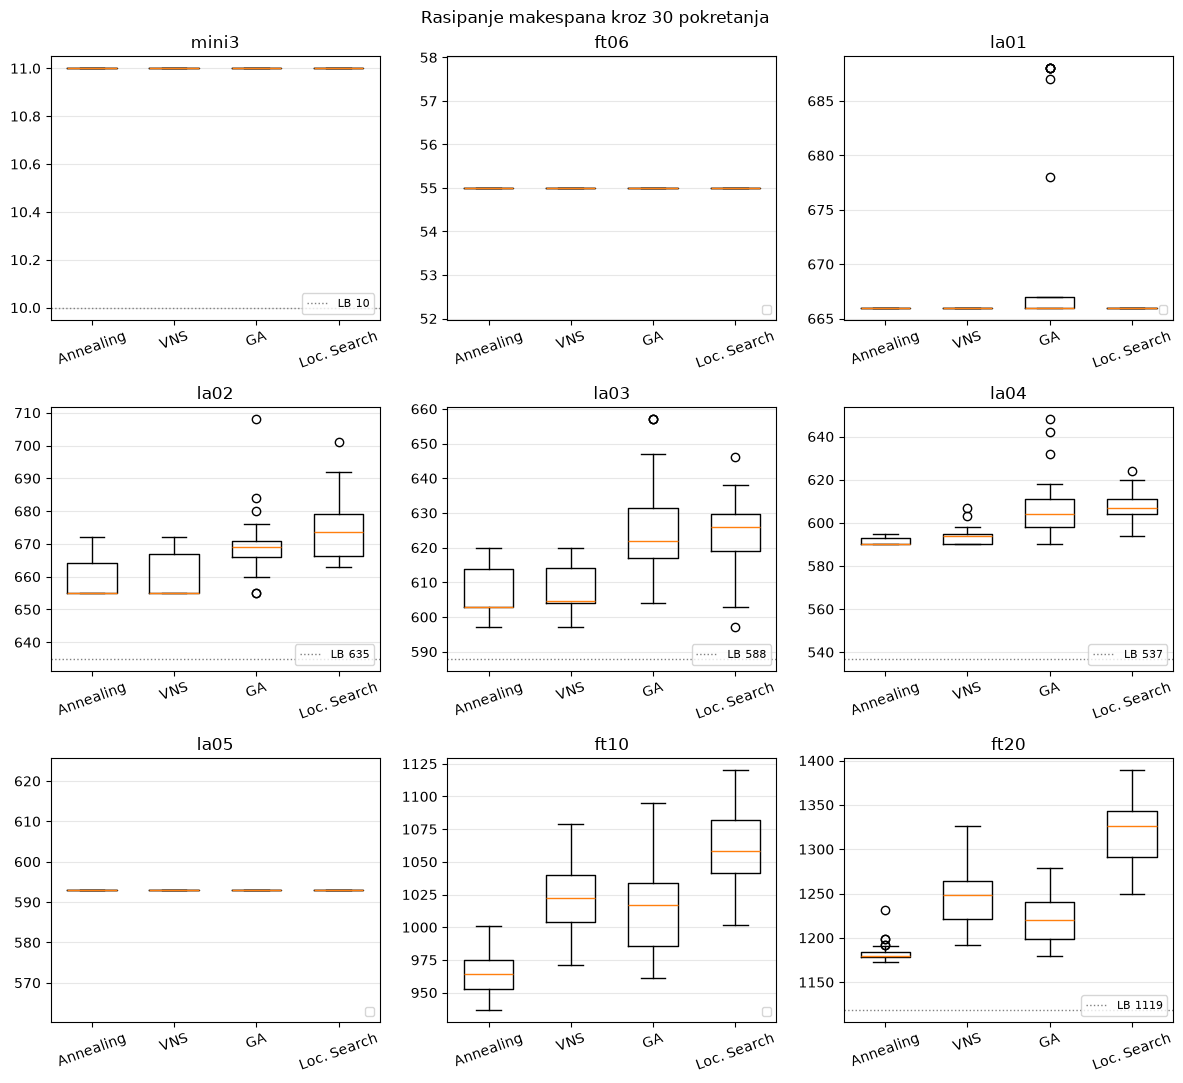

In [ ]:
fig, axes = plt.subplots(3,3,figsize=(12,11))
for ax, inst in zip(axes.ravel(), PROBLEMS):
    d = df[df.instance == inst]

    ax.boxplot([d[d.method == m].makespan for m in METHODS],
               tick_labels=LABELS, widths=0.6)

    opt = d.optimum.iloc[0]
    lb = d.lower_bound.iloc[0]

    if 0 < (opt - lb) / opt < 0.10:
        ax.axhline(lb, ls=":", c="0.5", lw=1, label=f"LB {lb}")
        ax.legend(fontsize=8,loc="lower right")

    ax.set_title(inst)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x",labelsize=10,rotation=20)

fig.suptitle("Rasipanje makespana kroz 30 pokretanja")
plt.tight_layout()


In [116]:
d = df.groupby(["instance", "method_label"]).makespan.describe()
d.head()

count        mean        std    min    25%    50%  \
instance method_label                                                      
ft06     Annealing      30.0   55.000000   0.000000   55.0   55.0   55.0   
         GA             30.0   55.000000   0.000000   55.0   55.0   55.0   
         Loc. Search    30.0   55.000000   0.000000   55.0   55.0   55.0   
         VNS            30.0   55.000000   0.000000   55.0   55.0   55.0   
ft10     Annealing      30.0  965.166667  16.263103  937.0  953.0  964.5   

                         75%     max  
instance method_label                 
ft06     Annealing      55.0    55.0  
         GA             55.0    55.0  
         Loc. Search    55.0    55.0  
         VNS            55.0    55.0  
ft10     Annealing     975.0  1001.0

In [117]:
t2 = d["min"].unstack().reindex(PROBLEMS).astype(int)
meta = df.groupby("instance")[["lower_bound","optimum"]].first().reindex(PROBLEMS)
t2 = pd.concat([meta,t2], axis=1)
t2

,lower_bound,optimum,Annealing,GA,Loc. Search,VNS
instance,,,,,,
mini3,10,11,11,11,11,11
ft06,47,55,55,55,55,55
la01,666,666,666,666,666,666
la02,635,655,655,655,663,655
la03,588,597,597,604,597,597
la04,537,590,590,590,594,590
la05,593,593,593,593,593,593
ft10,655,930,937,961,1002,971
ft20,1119,1165,1173,1180,1249,1192


In [118]:
extra = df.groupby(["instance","method_label"]).apply(
    lambda g: pd.Series({
        "hits": int((g.makespan == g.optimum).sum()),
        "opt. deviation": round((g.makespan - g.optimum).mean() / g.optimum.iloc[0] * 100,2),
        "time": round(g.time.mean(), 2)}),
    include_groups=False
)

t3 = pd.concat(
    [d[["min","mean","std","50%"]].round(2), extra], axis=1
).reindex(PROBLEMS, level = 0)
t3

min     mean    std     50%  hits  opt. deviation  \
instance method_label                                                         
mini3    Annealing       11.0    11.00   0.00    11.0  30.0            0.00   
         GA              11.0    11.00   0.00    11.0  30.0            0.00   
         Loc. Search     11.0    11.00   0.00    11.0  30.0            0.00   
         VNS             11.0    11.00   0.00    11.0  30.0            0.00   
ft06     Annealing       55.0    55.00   0.00    55.0  30.0            0.00   
         GA              55.0    55.00   0.00    55.0  30.0            0.00   
         Loc. Search     55.0    55.00   0.00    55.0  30.0            0.00   
         VNS             55.0    55.00   0.00    55.0  30.0            0.00   
la01     Annealing      666.0   666.00   0.00   666.0  30.0            0.00   
         GA             666.0   670.87   8.90   666.0  20.0            0.73   
         Loc. Search    666.0   666.00   0.00   666.0  30.0            0.00   
         VNS            666.0   666.00   0.00   666.0  30.0            0.00   
la02     Annealing      655.0   659.03   5.74   655.0  19.0            0.62   
         GA             655.0   669.93   9.41   669.0   2.0            2.28   
         Loc. Search    663.0   674.47   8.96   673.5   0.0            2.97   
         VNS            655.0   660.67   6.62   655.0  16.0            0.87   
la03     Annealing      597.0   606.23   7.40   603.0   5.0            1.55   
         GA             604.0   625.63  14.18   622.0   0.0            4.80   
         Loc. Search    597.0   623.87   9.91   626.0   1.0            4.50   
         VNS            597.0   607.60   6.97   604.5   3.0            1.78   
la04     Annealing      590.0   591.23   1.99   590.0  21.0            0.21   
         GA             590.0   606.03  14.18   604.0   4.0            2.72   
         Loc. Search    594.0   607.53   7.27   607.0   0.0            2.97   
         VNS            590.0   594.07   4.23   594.0  11.0            0.69   
la05     Annealing      593.0   593.00   0.00   593.0  30.0            0.00   
         GA             593.0   593.00   0.00   593.0  30.0            0.00   
         Loc. Search    593.0   593.00   0.00   593.0  30.0            0.00   
         VNS            593.0   593.00   0.00   593.0  30.0            0.00   
ft10     Annealing      937.0   965.17  16.26   964.5   0.0            3.78   
         GA             961.0  1012.07  30.93  1017.0   0.0            8.82   
         Loc. Search   1002.0  1059.63  29.96  1058.5   0.0           13.94   
         VNS            971.0  1023.77  24.70  1022.0   0.0           10.08   
ft20     Annealing     1173.0  1183.83  11.06  1180.0   0.0            1.62   
         GA            1180.0  1220.97  26.58  1220.5   0.0            4.80   
         Loc. Search   1249.0  1320.10  40.92  1326.5   0.0           13.31   
         VNS           1192.0  1245.80  29.91  1248.5   0.0            6.94   

                        time  
instance method_label         
mini3    Annealing      1.28  
         GA             3.59  
         Loc. Search    0.95  
         VNS            0.99  
ft06     Annealing      2.80  
         GA             7.67  
         Loc. Search    2.31  
         VNS            2.46  
la01     Annealing      3.90  
         GA            10.19  
         Loc. Search    3.42  
         VNS            3.70  
la02     Annealing      3.38  
         GA             9.03  
         Loc. Search    3.15  
         VNS            3.07  
la03     Annealing      3.20  
         GA             9.98  
         Loc. Search    3.00  
         VNS            3.30  
la04     Annealing      3.67  
         GA            10.18  
         Loc. Search    3.52  
         VNS            3.44  
la05     Annealing      3.78  
         GA            10.35  
         Loc. Search    3.58  
         VNS            3.40  
ft10     Annealing      7.00  
         GA            17.30  
         Loc. Search    6.46  


In [144]:
from matplotlib.patches import Patch 
from jsp import *
def gantt(instance, sequence, title="", ax=None, xmax=None):
    result = decode_full(instance,sequence)

    if not result['success']:
        return


    m = len({x for job in instance for x, _ in job})
    critical_path = set(result['critical_path'])

    if ax is None:
        _, ax = plt.subplots(figsize=(10,0.6*m + 1.2))

    colors = plt.cm.tab20(range(20))

    for j, job in enumerate(instance):
        for k, (mid, d) in enumerate(job):
            o = (j, k)
            ax.barh(y = mid, width=d, left=result['start'][o],
                    color = colors[j % 20],
                    # edgecolor='black' if o in critical_path else 'none',
                    hatch='///' if o in critical_path else None,
                    # zorder=5 if o in critical_path else 0
                    )



    ax.set_yticks(range(m))
    ax.set_yticklabels([f"M{i}" for i in range(m)])
    ax.invert_yaxis()
    ax.set_xlabel("time")
    ax.set_xlim(0,(xmax or result['makespan'])* 1.02)
    ax.set_title(f"{title}, makespan = {result['makespan']}")
    ax.grid(axis='x',alpha=0.3)

    handles = [Patch(facecolor=colors[j % 20], label=f"Job {j}") for j in range(len(instance))]
    handles.append(
        Patch(facecolor='white',edgecolor='black',hatch='///', label="crit. path")
    )
    if len(instance) <= 6:
        ax.legend(handles=handles,
                fontsize=8, ncol=2)
    return result['makespan']

In [131]:
METHODS_FN = {"annealing":    simulated_annealing,
              "vns":          vns,
              "ga":           genetic_algorithm,
              "local_search": local_search_budget}

def reproduce_seq(inst_name, method_name, column="min"):
    d = df[(df.instance == inst_name) & (df.method == method_name)]
    r = d.loc[d.makespan.idxmin() if column == "min" else d.makespan.idxmax()]

    inst = load(f"data/{inst_name}.txt")
    base = [j for j, job in enumerate(inst) for _ in job]
    random.seed(int(r.seed))
    start = random.sample(base,len(base))

    v, seq = METHODS_FN[method_name](inst, start, budget=BUDGET)
    assert v == r.makespan, f"{v} != {r.makespan}"
    return inst, seq, v

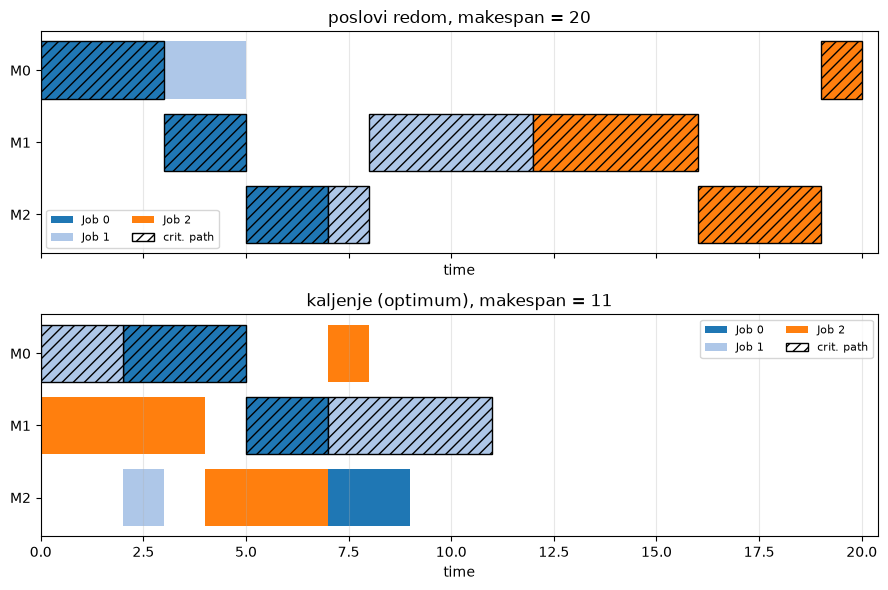

In [140]:
mini3 = load("data/mini3.txt")
los = [j for j in range(3) for _ in range(3)]
_, opt_seq, _ = reproduce_seq("mini3", "annealing")
scale = decode_full(mini3, los)['makespan']

fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
gantt(mini3, los,     "poslovi redom", ax[0], xmax=scale)
gantt(mini3, opt_seq, "kaljenje (optimum)", ax[1], xmax=scale)
plt.tight_layout()

937

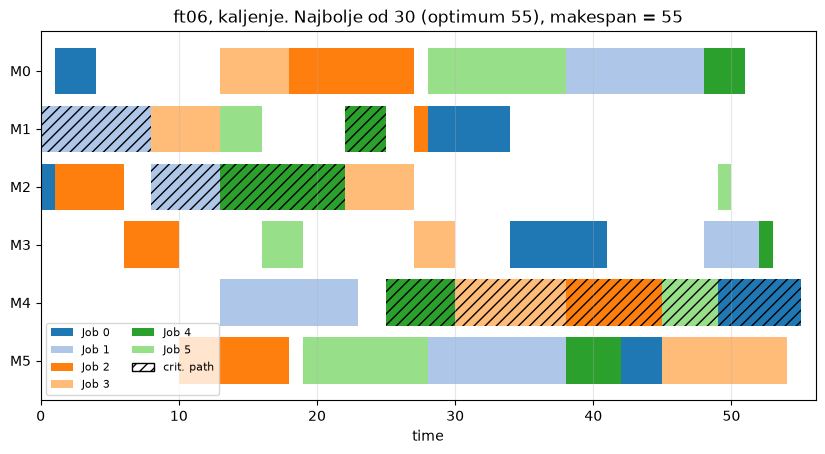

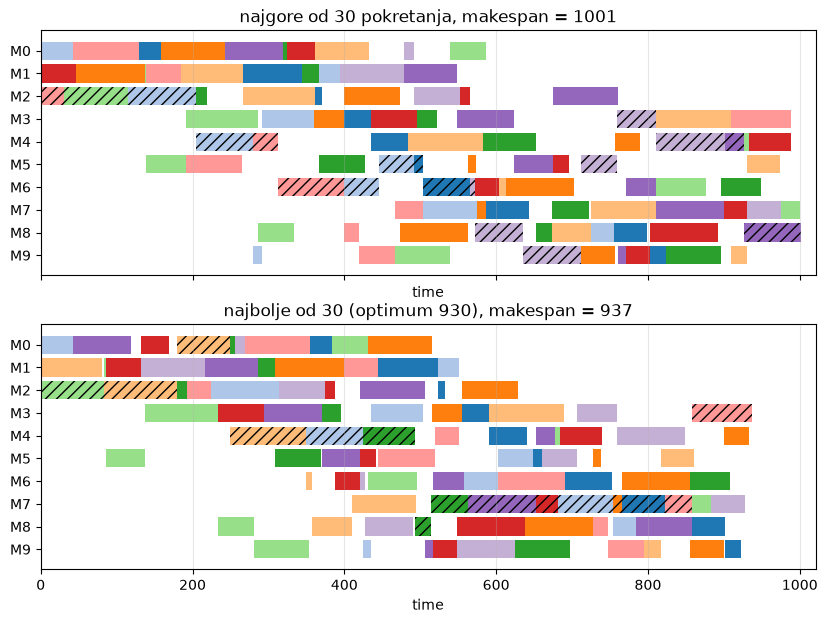

In [145]:
inst, seq, v = reproduce_seq("ft06", "annealing")
gantt(inst, seq, "ft06, kaljenje. Najbolje od 30 (optimum 55)")

inst, s_best, v_best = reproduce_seq("ft10", "annealing")
_,    s_worst, v_worst = reproduce_seq("ft10", "annealing", "max")
fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
gantt(inst, s_worst, "najgore od 30 pokretanja", ax[0], xmax=v_worst)
gantt(inst, s_best, "najbolje od 30 (optimum 930)", ax[1], xmax=v_worst)

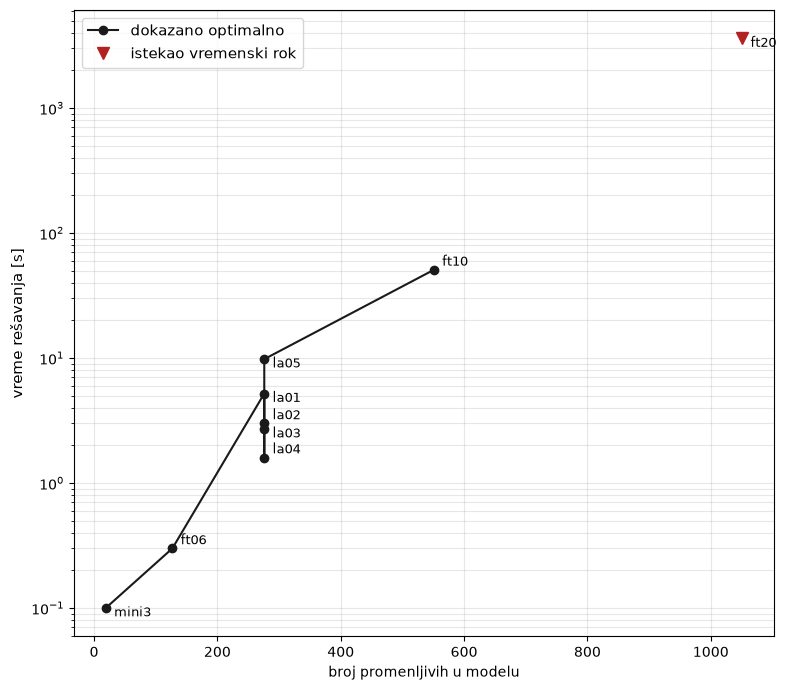

In [186]:
d = pd.read_csv("results/ilp.csv").sort_values("num_vars")
res = d[d.proven]
nres = d[~d.proven]

fig, ax = plt.subplots(figsize=(8,7))
ax.plot(res.num_vars, res.time, "o-", color="0.1", ms=6, label="dokazano optimalno")
ax.plot(nres.num_vars, nres.time, "v", color="firebrick", ms=9, label="istekao vremenski rok")

for i, r in d.iterrows():
    ax.annotate(r.instance, (r.num_vars, r.time),
                textcoords="offset points", 
                xytext=(6, -6) if int(i) % 2 == 0 else (6,3),
                 fontsize=9,)

ax.set_yscale("log")
ax.set_xlabel("broj promenljivih u modelu")
ax.set_ylabel("vreme rešavanja [s]",fontsize=11)
ax.grid(alpha=.3, which="both")
ax.legend(fontsize=11)

plt.tight_layout()

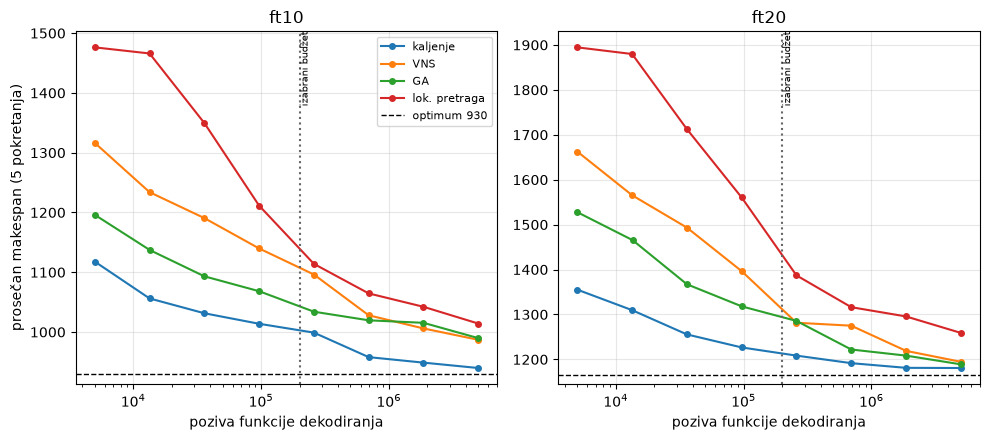

In [179]:
df = pd.read_csv("results/budget.csv")
NAME_MAP = {"annealing": "kaljenje", "vns": "VNS",
       "ga": "GA", "local_search": "lok. pretraga"}

INSTANCES = [("ft10", 930), ("ft20", 1165)]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, (inst_name, opt) in zip(axes, INSTANCES):
    d = df[df.instance == inst_name]
    for met_name, label in NAME_MAP.items():
        m = d[d.method == met_name].sort_values("decode_calls")
        ax.plot(m.decode_calls, m.average, marker="o", ms=4, label=label)

    ax.axhline(opt, ls="--", c="k", lw=1, label=f"optimum {opt}")
    ax.axvline(200_000, ls=":", c="0.4", lw=1.5)
    ax.text(200_000, ax.get_ylim()[1], " izabrani budžet",
            fontsize=7, va="top", rotation=90)

    ax.set_xscale("log")
    ax.set_title(inst_name)
    ax.set_xlabel("poziva funkcije dekodiranja")
    ax.grid(alpha=.3)
axes[0].set_ylabel("prosečan makespan (5 pokretanja)")
axes[0].legend(fontsize=8)
plt.tight_layout()